# WarehouseSort — Starter Notebook

This notebook walks through the **state IL pipeline** (main track) end-to-end on the easy level:
install → look at the env → download demos → train a state Diffusion Policy → evaluate.

The policy reads the **privileged low-dim state vector** (proprioception + parcel poses & tag
colors + bin positions). The provided state Diffusion Policy is your starting point — your job is to improve it. *(An optional harder image/rgb track exists too — see
the README.)*

**Requirements:** a CUDA GPU. In Google Colab: *Runtime → Change runtime type → T4 GPU*.

References:
- [ManiSkill 3](https://maniskill.readthedocs.io/en/latest/) — GPU-accelerated robot simulation
- [Diffusion Policy](https://diffusion-policy.cs.columbia.edu) — Chi et al. 2023

### What a solved episode looks like

The scripted policy (used only to generate the demos) sorting parcels into the
color-matched bins — left panel is the scene view, right is the policy's camera:

![easy demo](https://github.com/marso-robotics/berlin-marso-hackathon/raw/main/media/easy_demo.gif)

*(medium = 4 parcels, hard = 6 parcels with bins that may swap sides — see the README.)*

## 1. Install

In [2]:
# Install ManiSkill and dependencies (takes ~2 min on Colab)
!pip install mani-skill==3.0.1 diffusers==0.38.0 gymnasium torch torchvision hydra-core matplotlib -q

# Clone the repo (skip if already in the repo directory)
import os
if not os.path.exists('warehouse_sort'):
    !git clone https://github.com/marso-robotics/berlin-marso-hackathon.git
    %cd berlin-marso-hackathon

# Install the package
!pip install -e . -q

# Colab headless rendering (offscreen Vulkan)
import os
os.environ['DISPLAY'] = ''
os.environ['PYOPENGL_PLATFORM'] = 'egl'

## 2. Look at the environment

**Easy level**: 2 parcels (1 red-tagged, 1 blue-tagged), 2 color-coded bins, fixed positions.
The observation is the **state vector**: robot proprioception + parcel poses & tag colors + bin
positions & colors. Its size depends on the parcel count, so a state policy is **level-specific**.

In [3]:
import platform
import gymnasium as gym
import torch
import warehouse_sort  # registers WarehouseSort-v1 + Windows CUDA shim

# Vulkan rendering crashes on native Windows; use Colab/Linux to preview frames.
_render = None if platform.system() == 'Windows' else 'rgb_array'

env = gym.make(
    'WarehouseSort-v1', num_envs=1, obs_mode='state',
    control_mode='pd_ee_delta_pos', sim_backend='gpu', render_mode=_render,
    difficulty='easy', num_parcels=2, fixed_poses=True,
)

obs, _ = env.reset(seed=42)
print('state obs shape:', tuple(obs.shape))            # (1, 54) for easy (2 parcels)
print('action space   :', env.action_space)             # Box(-1,1,(4,))
print()
print('The state vector includes parcel poses, tag colors, and bin positions —')
print('its length grows with the parcel count, so train one model per level.')

state obs shape: (1, 54)
action space   : Box(-1.0, 1.0, (4,), float32)

The state vector includes parcel poses, tag colors, and bin positions —
its length grows with the parcel count, so train one model per level.


Inline camera render unavailable on Windows (Vulkan offscreen + GPU sim).
Showing top-down plot from state obs. Run the next cell for a live 3D viewer.


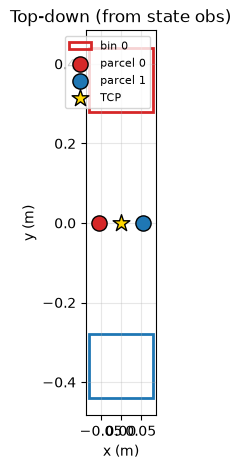

In [4]:
# Visualize the scene
# Windows: offscreen env.render() crashes with GPU sim — use the plot below or the 3D viewer cell.
import platform
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display
import PIL.Image, io
from warehouse_sort.viz import plot_state_topdown

if platform.system() == 'Windows':
    print('Inline camera render unavailable on Windows (Vulkan offscreen + GPU sim).')
    print('Showing top-down plot from state obs. Run the next cell for a live 3D viewer.')
    fig, ax = plt.subplots(figsize=(6, 5))
    plot_state_topdown(obs, num_parcels=env.unwrapped.num_parcels, ax=ax)
    plt.show()
else:
    frame = env.render()                    # (1, H, W, 3) uint8
    img = PIL.Image.fromarray(frame[0].cpu().numpy())
    buf = io.BytesIO()
    img.save(buf, format='PNG')
    display(IPImage(buf.getvalue()))

In [5]:
# Windows: open the live SAPIEN 3D viewer (render_mode='human' works; rgb_array offscreen does not).
import platform
if platform.system() == 'Windows':
    env.close()
    env = gym.make(
        'WarehouseSort-v1', num_envs=1, obs_mode='state',
        control_mode='pd_ee_delta_pos', sim_backend='gpu', render_mode='human',
        difficulty='easy', num_parcels=2, fixed_poses=True,
        sensor_configs=dict(shader_pack='minimal'),
    )
    env.reset(seed=42)
    env.render()   # opens an interactive window — rotate/zoom with mouse
    print('Close the viewer window when done, then continue the notebook.')
else:
    print('On Colab/Linux, use the camera image in the cell above.')

Close the viewer window when done, then continue the notebook.


In [6]:
# Run the scripted waypoint policy to verify the env works (it generates the demos;
# it reads privileged sim state to control the arm, so it is NOT a submittable policy).
import sys, platform
sys.path.insert(0, '.')
from examples.scripted_policy import scripted_episode

env.close()
_render = None if platform.system() == 'Windows' else 'rgb_array'
env = gym.make('WarehouseSort-v1', num_envs=1, obs_mode='state',
               control_mode='pd_ee_delta_pos', sim_backend='gpu', render_mode=_render,
               difficulty='easy', num_parcels=2, fixed_poses=True, max_episode_steps=200)
history = scripted_episode(env, max_steps=200, seed=42)
final_info = history[-1][-1]
print(f"Sorted: {final_info['success_count'].item():.0f} / 2")
env.close()

  step   0  phase=OPEN      parcel=0  tcp=[-0.    0.    0.17]  sorted=0.0
  step  20  phase=GRASP     parcel=0  tcp=[-0.061 -0.     0.062]  sorted=0.0
  step  40  phase=CARRY     parcel=0  tcp=[-0.019  0.085  0.286]  sorted=0.0
  step  60  phase=ABOVE     parcel=1  tcp=[-0.01   0.353  0.099]  sorted=1.0
  step  80  phase=GRASP     parcel=1  tcp=[ 0.05  -0.     0.059]  sorted=1.0
  step 100  phase=CARRY     parcel=1  tcp=[ 0.014 -0.059  0.3  ]  sorted=1.0
Sorted: 2 / 2


## 3. Demonstrations (provided — Kaggle competition data)

The demos (**200 episodes per level**, state for the main track) are the competition data:
[the data tab](https://www.kaggle.com/competitions/marso-hack-berlin-2026-robot-parcel-sorting-challenge/data). You don't need to record any.

- **On Kaggle** (notebook attached to the competition): the data is already mounted under
  `/kaggle/input/` — nothing to set up; the cell below finds it.
- **On Colab / local**: the cell downloads it with `kagglehub`, which needs your Kaggle API
  credentials (one-time). First **join the competition** (Rules → *I Understand and Accept*),
  then get a token: on kaggle.com click your **avatar → Settings → API → Create New API Token**.
  (Ensure you use the legacy method to download `kaggle.json` containing your `username` and `key`). Then set them in the cell —
  the auth lines are at the top, just uncomment and paste your values.

Either way the cell stages the files under `il/demos/<level>/` so the training commands below
work unchanged.

> ⚠️ The demos come from a scripted policy. Using it to collect *data* is fine, but submitting a
> scripted / hard-coded controller (or any policy that reads privileged env state) is
> **disqualified** — your submitted policy must act from the observation.

In [7]:
# The demos (200 episodes per level) are the Kaggle COMPETITION data.
COMPETITION = 'marso-hack-berlin-2026-robot-parcel-sorting-challenge'

import os, sys
sys.path.insert(0, '.')

# --- Colab / local auth (NOT needed on Kaggle) -------------------------------------------
# After joining the competition, get a token from kaggle.com -> Settings -> API ->
# 'Create New API Token' (downloads kaggle.json), then uncomment and paste its values:
os.environ['KAGGLE_USERNAME'] = 'unrealdrip'
os.environ['KAGGLE_KEY']      = '412081ee9034f8cc6665fe2560ecb92b'      # the 'key' field in kaggle.json
# (Alternatively run  `import kagglehub; kagglehub.login()`  for an interactive prompt.)
# -----------------------------------------------------------------------------------------

from il.download_demos import fetch_and_stage

# Downloads easy + medium + hard (~389 MB). Re-runs force a fresh download if the cache is stale.
fetch_and_stage(COMPETITION)

data at: C:\Users\soman\.cache\kagglehub\competitions\marso-hack-berlin-2026-robot-parcel-sorting-challenge
staged levels: ['easy', 'hard', 'medium']


['easy', 'hard', 'medium']

In [8]:
# Check all three state demo levels are present
import glob
for lvl in ('easy', 'medium', 'hard'):
    files = sorted(glob.glob(f'il/demos/{lvl}/*.state*.h5'))
    print(f'{lvl}:', files[0] if files else 'MISSING')

easy: il/demos/easy\trajectory.state.pd_ee_delta_pos.physx_cuda.h5
medium: il/demos/medium\trajectory.state.pd_ee_delta_pos.physx_cuda.h5
hard: il/demos/hard\trajectory.state.pd_ee_delta_pos.physx_cuda.h5


### 📈 Watch training live with TensorBoard

Run the two lines below **before** the training cell. `%tensorboard` starts a background
server and embeds a dashboard that **auto-refreshes as training writes metrics** (loss,
eval sort accuracy), so you can keep watching while the training cell runs.


In [9]:
%load_ext tensorboard
%tensorboard --logdir il/baselines/diffusion_policy/runs

Reusing TensorBoard on port 6006 (pid 17280), started 0:45:44 ago. (Use '!kill 17280' to kill it.)

## 4. Train the state Diffusion Policy

[Diffusion Policy](https://diffusion-policy.cs.columbia.edu) (Chi et al. 2023): a plain MLP
behavior cloner fails due to compounding error; DP's action chunking fixes it.

This uses a short run (`total_iters=10000`) to verify the pipeline. **For real training scale up
to `total_iters=30000`+** (~20–40 min on a T4 for easy; more for medium/hard).

> ⚠️ **One model per level.** The state vector's size depends on the parcel count, so a checkpoint
> is specific to its level — train (and submit) a separate one for easy, medium, and hard.

In [1]:
# -u = unbuffered so Jupyter shows output in real time
# 2>&1 merges stderr into stdout so nothing gets swallowed
!python -u il/train.py method=dp demo_dir=easy \
    flags.total_iters=5000 \
    flags.batch_size=128 \
    flags.log_freq=500 \
    flags.save_freq=2000 \
    flags.eval_freq=0 \
    flags.obs_horizon=2 \
    flags.act_horizon=8 \
    flags.pred_horizon=16 \
    flags.exp_name=warehouse_state_dp_starter 2>&1

^C


In [ ]:
# For real training (uncomment and run)
# !python il/train.py method=dp demo_dir=easy \
#     flags.total_iters=30000 \
#     flags.eval_freq=5000 \
#     flags.exp_name=warehouse_state_dp_easy

## 5. Evaluate the checkpoint

In [27]:
import glob, os

# Find the latest checkpoint
ckpts = sorted(glob.glob(
    'il/baselines/diffusion_policy/runs/warehouse_state_dp_starter/checkpoints/*.pt'
))
if not ckpts:
    print('No checkpoint found — run training first')
else:
    ckpt = ckpts[-1]
    print(f'Using checkpoint: {ckpt}')
    !python eval.py difficulty=easy \
        policy=warehouse_sort.il_policy:load_dp \
        checkpoint={ckpt} \
        eval_config=conf/eval/default.yaml

No checkpoint found — run training first


**Watch the rollout.** `eval.py` prints the metrics above and saves a rollout video (render + policy-camera views). Display it below — with the untrained template the arm mostly flails, which is exactly the gap you're closing.

In [ ]:
# Display the eval rollout video (eval.py saves one under outputs/<date>/<time>/videos/)
import glob, os
from IPython.display import Video, display
vids = sorted(glob.glob('outputs/**/videos/*.mp4', recursive=True), key=os.path.getmtime)
if vids:
    print('eval rollout:', vids[-1])
    display(Video(vids[-1], embed=True, width=640))
else:
    print('No eval video found — run the eval cell above first.')

## 6. Scaling to medium and hard

Medium (4 parcels) and hard (6 parcels) use the **same pipeline** — but because the state vector
is parcel-count-specific you must **train a separate checkpoint per level** (you can't reuse the
easy model). Just change `demo_dir` and `difficulty`:

```bash
python il/train.py method=dp demo_dir=medium flags.total_iters=50000 flags.exp_name=warehouse_state_dp_medium
python eval.py difficulty=medium policy=warehouse_sort.il_policy:load_dp \
    checkpoint=il/baselines/diffusion_policy/runs/warehouse_state_dp_medium/checkpoints/best_eval_sort_accuracy.pt \
    eval_config=conf/eval/default.yaml

python il/train.py method=dp demo_dir=hard flags.total_iters=60000 flags.exp_name=warehouse_state_dp_hard
python eval.py difficulty=hard policy=warehouse_sort.il_policy:load_dp \
    checkpoint=il/baselines/diffusion_policy/runs/warehouse_state_dp_hard/checkpoints/best_eval_sort_accuracy.pt \
    eval_config=conf/eval/default.yaml
```

Tip: a longer `flags.pred_horizon` (e.g. 32) can help on the longer-horizon levels.

## 7. Optional — image-based track (harder)

Want a harder, more realistic challenge? Try the **RGB** track: the policy sees only a
scene-camera image + proprioception — **no privileged state**. The competition data already
includes the rgb demos (staged in §3), and because the image has a fixed shape, **one rgb
checkpoint can run on all levels**. It's a **template that does not yet solve the task** —
getting an image policy to sort is an open problem.

```bash
# train the RGB Diffusion Policy (ResNet18 + SpatialSoftmax encoder)
python il/train.py method=dp_rgb demo_dir=easy flags.exp_name=warehouse_rgb_dp

# evaluate it (obs_mode=rgb, load_dp_rgb)
python eval.py difficulty=easy obs_mode=rgb \
    policy=warehouse_sort.il_policy:load_dp_rgb \
    checkpoint=il/baselines/diffusion_policy/runs/warehouse_rgb_dp/checkpoints/best_eval_sort_accuracy.pt \
    eval_config=conf/eval/default.yaml
```

## 8. Next steps — how to submit

You've trained and evaluated a policy. From here:

1. **Push to medium and hard** (§6) — they carry the most weight (medium 0.3, hard 0.5).
2. **Or bring your own approach** — any policy that implements the
   `act(obs, deterministic=True)` contract works (RL, scripted, transformer, ...).
3. **Package your entry** — you submit a **GitHub repo** containing your policy
   entrypoint, your checkpoint(s), and a `submission.yaml` declaring the levels +
   checkpoint for each.

**Read [SUBMISSION.md](https://github.com/marso-robotics/berlin-marso-hackathon/blob/main/SUBMISSION.md)**
for the full guide: how the code ties together, the policy contract (with a minimal
example), how to declare what gets scored, and exactly how to submit.

> If you're on Colab, `SUBMISSION.md` and `submission.example.yaml` are also in the
> repo you cloned in step 1 — open them from the file browser on the left.


**What you submit (3 things):** your **codebase** (this repo, forked) · a **`submission.yaml`** (per-level checkpoint) · your **checkpoint(s)** plus the **policy entrypoint** `module:function` that loads them into `act(obs)`.

### Ideas to improve the baseline

- **Train longer / more data**: raise `flags.total_iters`; record more demos with `il/gen_demos.py`.
- **Horizons**: `flags.pred_horizon`, `flags.act_horizon`, `flags.obs_horizon`.
- **Eval denoising steps**: `num_inference_steps` in `load_dp` (more = better, slower).
- **Capacity**: `unet_dims`, `diffusion_step_embed_dim`; **optimisation**: `flags.batch_size`, LR.
- **Generalise** to the held-out wider positions / bin-swaps (hard is weighted 0.5).

> ⚠️ If you change an architecture/horizon hyperparameter for training, pass the **same** value to your policy loader (`load_dp(...)`) or the checkpoint won't load.